In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import scanpy as sc
import scvelo as scv
import numpy as np

cwd = Path.cwd()
ANALYSIS_DIR = (
    cwd
    if cwd.name == "03_pancreas_endocrinogenesis"
    else Path("03_pancreas_endocrinogenesis")
    if Path("03_pancreas_endocrinogenesis").exists()
    else Path(".")
)
DATA_DIR = Path("data/flowmap_manuscript/pancreas")
if not DATA_DIR.exists():
    DATA_DIR = Path("../data/flowmap_manuscript/pancreas")
FIGURE_DIR = ANALYSIS_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(DATA_DIR / "pancreas_inferred_velocity.h5ad")
n_pcs = 50

# Use the matrix YOU trust (usually adata.X or adata.layers["Ms"])
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X

# Optional: standardize (recommended if you want PCA to behave)
X = StandardScaler(with_mean=True, with_std=True).fit_transform(X)

# Optional: "stretch PCA" (identity by default; customize if needed)
stretch = np.ones(X.shape[1])   # <- replace with gene-wise stretch if desired
X = X * stretch

# PCA
pca = PCA(n_components=n_pcs, svd_solver="arpack", random_state=0)
X_pca = pca.fit_transform(X)

# --------------------------
# OVERWRITE PCA IN ADATA
# --------------------------
adata.obsm["X_pca"] = X_pca
adata.varm["PCs"] = pca.components_.T
adata.uns["pca"] = {
    "variance": pca.explained_variance_,
    "variance_ratio": pca.explained_variance_ratio_,
}

print("✅ Overwrote PCA:", adata.obsm["X_pca"].shape)

In [ ]:
scv.tl.velocity(adata, mode="stochastic", vkey="stochastic_velocity")
scv.tl.velocity_graph(adata, vkey="stochastic_velocity")

scv.tl.velocity(adata, mode="dynamical", vkey="dynamical_velocity")
scv.tl.velocity_graph(adata, vkey="dynamical_velocity")

In [ ]:
if "stochastic_velocity_pca" not in adata.obsm:
    print("Computing stochastic_velocity_pca...")
    scv.tl.velocity_embedding(adata, basis="pca", vkey="stochastic_velocity")

V_pca_stoch = adata.obsm["stochastic_velocity_pca"]

# Compute ONLY if missing
if "dynamical_velocity_pca" not in adata.obsm:
    print("Computing dynamical_velocity_pca...")
    scv.tl.velocity_embedding(adata, basis="pca", vkey="dynamical_velocity")

In [ ]:
from flowmap import *

X = adata.obsm["X_pca"]
V = adata.obsm["stochastic_velocity_pca"]
X_umap = adata.obsm["X_umap"]
cell_type = adata.obs["clusters"]

emb = VectorFieldEmbedder(X, V, dist_method="phase",
                          dof=30, X_emb = X_umap,
                          embed_kwargs={"n_neighbors":30,
                                                    "min_dist":0.5,
                                                    "spread":1.0})
emb.fit_embedding(seed=0)
# plot_velocity_streamplot(
#     X_2d=emb.X_emb,
#     tps_vf=emb.tps_vf,
#     scatter_color=cell_type,
#     grid_density=1.0, 
#     stream_density=1.2,
#     scatter_size=200,
#     scatter_alpha=0.2,
#     figsize=(8, 8),
#     aspect=1,
#     vmin=0.0,
#     vmax=1.0,
#     cmap="tab10",
#     grid_size=50
# )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from sklearn.neighbors import NearestNeighbors

import flowmap
from flowmap.utils import compute_velocity_on_grid


# ------------------------------------------------------------------
# Helper: trim grid points outside the data manifold
# ------------------------------------------------------------------
def points_inside_mask(X, seeds, k=8, radius_scale=1.2):
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    r = np.median(nn.kneighbors(X)[0][:, -1]) * radius_scale
    idx = nn.radius_neighbors(seeds, radius=r, return_distance=False)
    return np.array([len(i) > 0 for i in idx])


# ------------------------------------------------------------------
# 1) Embedding + colors
# ------------------------------------------------------------------
X_emb = emb.X_emb

cluster_key = "clusters"
labels = adata.obs[cluster_key].values
categories = adata.obs[cluster_key].cat.categories
colors = np.asarray(adata.uns[f"{cluster_key}_colors"])

colmap = dict(zip(categories, colors))
cell_colors = np.array([colmap[l] for l in labels])


# ------------------------------------------------------------------
# 2) Velocity grid (FlowMap utility)
# ------------------------------------------------------------------
Xg, keep, Vg, _ = compute_velocity_on_grid(
    X_emb,
    spline_vf=emb.spline_vf,
    grid_size=22,
    min_mass=0.01,
    return_mesh=True
)

# Trim boundary
mask = points_inside_mask(X_emb, Xg)
Xg = Xg[mask]
Vg = Vg[mask]


# ------------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))

# Cell scatter
ax.scatter(
    X_emb[:, 0], X_emb[:, 1],
    c=cell_colors,
    s=60,
    alpha=0.35,
    linewidths=0
)

# Velocity field
ax.quiver(
    Xg[:, 0], Xg[:, 1],
    Vg[:, 0], Vg[:, 1],
    angles="xy",
    scale_units="xy",
    scale=0.1,
    width=0.004,
    headwidth=4.5,
    headlength=3.0,
    headaxislength=2.3,
    minlength=0.2,
    color="k",
    alpha=0.9
)


# ------------------------------------------------------------------
# 4) Cell-type labels
# ------------------------------------------------------------------
for ct in np.unique(labels):

    idx = labels == ct
    if idx.sum() == 0:
        continue

    x_center = np.median(X_emb[idx, 0])
    y_center = np.median(X_emb[idx, 1])

    txt = ax.text(
        x_center,
        y_center,
        str(ct),
        ha="center",
        va="center",
        fontsize=10,
        color="black",
        alpha=0.7,
        zorder=10
    )

    txt.set_path_effects([
        pe.Stroke(linewidth=2.5, foreground="white"),
        pe.Normal(),
    ])


# ------------------------------------------------------------------
# 5) Clean axes
# ------------------------------------------------------------------
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

for s in ax.spines.values():
    s.set_visible(False)

plt.tight_layout()

# ------------------------------------------------------------------
# 6) Save figure
# ------------------------------------------------------------------
import os

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "velocity_grid_pancreas.pdf")
fig.savefig(save_path, bbox_inches="tight")

print(f"Saved to: {save_path}")

# ------------------------------------------------------------------
# 7) Show
# ------------------------------------------------------------------
fig.canvas.draw_idle()
plt.show()

In [ ]:
X = adata.layers["spliced"]
V = adata.layers["stochastic_velocity"]

# Convert to dense if sparse
if hasattr(X, "toarray"):
    X = X.toarray()
if hasattr(V, "toarray"):
    V = V.toarray()

emb.fit_gene_level_splines(
    dof_gene=30,
    dof_vf_gene=30,
    X=X,
    V=V,
)

In [ ]:
from flowmap.evaluation import SplineFitEvaluator

cell_types = adata.obs["clusters"].unique().tolist()

results_by_cell_type = {}

for ct in cell_types:

    print(f"\n=== Evaluating cell type: {ct} ===")

    # --------------------------------------------------
    # Cell indices for this type
    # --------------------------------------------------
    cell_idx = np.where(adata.obs["clusters"].values == ct)[0]

    if len(cell_idx) < 10:
        print(f"[Skip] Too few cells ({len(cell_idx)})")
        continue

    # --------------------------------------------------
    # Evaluator
    # --------------------------------------------------
    evaluator = SplineFitEvaluator(
        emb, mode="gene"
    )

    # --------------------------------------------------
    # Main evaluation
    # --------------------------------------------------
    res = evaluator.evaluate(cell_idx=cell_idx)

    # --------------------------------------------------
    # Optional permutation test
    # --------------------------------------------------
    # perm = evaluator.permutation_pvals(
    #     res,
    #     n_perm=500,
    #     n_bins=20,
    #     random_state=0,
    # )

    results_by_cell_type[ct] = {
        "n_cells": len(cell_idx),
        "eval": res,
        # "perm": perm,
    }

print("\nDone. Results stored in `results_by_cell_type`.")

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18
})

sns.set_style("whitegrid")

# ------------------------------------------------------------
# Pick cell type
# ------------------------------------------------------------
ct = "Ductal"
res = results_by_cell_type[ct]["eval"]

# ------------------------------------------------------------
# Build one aligned dataframe
# ------------------------------------------------------------
df = pd.DataFrame({
    "expr_corr": np.asarray(res["expr_corr_gene"]),
    "vel_corr": np.asarray(res["vel_corr_gene"]),
    "gene": np.asarray(adata.var.index),
})

df = df[np.isfinite(df["expr_corr"]) & np.isfinite(df["vel_corr"])].copy()

# optional: keep only nonnegative correlations
# df = df[(df["expr_corr"] >= 0) & (df["vel_corr"] >= 0)].copy()

df["score"] = df["expr_corr"] * df["vel_corr"]
df["is_top"] = False

top_k = 10
top_rows = df["score"].nlargest(top_k).index
df.loc[top_rows, "is_top"] = True

print(df.loc[df["is_top"], ["gene", "expr_corr", "vel_corr", "score"]].sort_values("score", ascending=False))


g = sns.JointGrid(data=df, x="expr_corr", y="vel_corr", height=7)

# Remove marginals
g.ax_marg_x.remove()
g.ax_marg_y.remove()

ax = g.ax_joint

# Background
sns.scatterplot(
    data=df.loc[~df["is_top"]],
    x="expr_corr",
    y="vel_corr",
    color="lightgrey",
    s=50,
    alpha=0.4,
    edgecolor="none",
    ax=ax,
)

# Highlight
sns.scatterplot(
    data=df.loc[df["is_top"]],
    x="expr_corr",
    y="vel_corr",
    color="#d62728",
    s=240,
    alpha=0.95,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

# Regression
sns.regplot(
    data=df,
    x="expr_corr",
    y="vel_corr",
    scatter=False,
    color="crimson",
    line_kws={"lw": 2.5, "alpha": 0.8},
    ax=ax
)

ax = g.ax_joint

# --------------------------------
# Let matplotlib set limits FIRST
# --------------------------------
# --- draw everything first (scatter, regplot, etc.) ---

# Reference lines (these may expand limits, that's fine)
g.ax_joint.axhline(0, color="grey", ls="--", lw=1.2, alpha=0.5)
g.ax_joint.axvline(0, color="grey", ls="--", lw=1.2, alpha=0.5)

# ----------------------------------------------------
# YOUR CUSTOM TICKS (you choose these numbers)
# ----------------------------------------------------
xticks = [0.0, 1.0]     # <-- CHANGE THESE
yticks = [-0.5, 0.5]    # <-- CHANGE THESE

ax = g.ax_joint

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels([f"{t:.2f}" for t in xticks], fontsize=30)
ax.set_yticklabels([f"{t:.2f}" for t in yticks], fontsize=30)

# ----------------------------------------------------
# REMOVE ALL OTHER CLUTTER
# ----------------------------------------------------
ax.tick_params(length=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

sns.despine(ax=ax)

plt.tight_layout()

# Save
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"gene_concordance_{ct}.pdf")
g.figure.savefig(save_path, bbox_inches="tight")

print("Saved to:", save_path)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18
})

sns.set_style("whitegrid")

# ------------------------------------------------------------
# Pick cell type
# ------------------------------------------------------------
ct = "Ngn3 high EP"
res = results_by_cell_type[ct]["eval"]

# ------------------------------------------------------------
# Build one aligned dataframe
# ------------------------------------------------------------
df = pd.DataFrame({
    "expr_corr": np.asarray(res["expr_corr_gene"]),
    "vel_corr": np.asarray(res["vel_corr_gene"]),
    "gene": np.asarray(adata.var.index),
})

df = df[np.isfinite(df["expr_corr"]) & np.isfinite(df["vel_corr"])].copy()

# optional: keep only nonnegative correlations
# df = df[(df["expr_corr"] >= 0) & (df["vel_corr"] >= 0)].copy()

df["score"] = df["expr_corr"] * df["vel_corr"]
df["is_top"] = False

top_k = 10
top_rows = df["score"].nlargest(top_k).index
df.loc[top_rows, "is_top"] = True

print(df.loc[df["is_top"], ["gene", "expr_corr", "vel_corr", "score"]].sort_values("score", ascending=False))


g = sns.JointGrid(data=df, x="expr_corr", y="vel_corr", height=7)

# Remove marginals
g.ax_marg_x.remove()
g.ax_marg_y.remove()

ax = g.ax_joint

# Background
sns.scatterplot(
    data=df.loc[~df["is_top"]],
    x="expr_corr",
    y="vel_corr",
    color="lightgrey",
    s=50,
    alpha=0.4,
    edgecolor="none",
    ax=ax,
)

# Highlight
sns.scatterplot(
    data=df.loc[df["is_top"]],
    x="expr_corr",
    y="vel_corr",
    color="#d62728",
    s=240,
    alpha=0.95,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

# Regression
sns.regplot(
    data=df,
    x="expr_corr",
    y="vel_corr",
    scatter=False,
    color="crimson",
    line_kws={"lw": 2.5, "alpha": 0.8},
    ax=ax
)

ax = g.ax_joint

# --------------------------------
# Let matplotlib set limits FIRST
# --------------------------------
# --- draw everything first (scatter, regplot, etc.) ---

# Reference lines (these may expand limits, that's fine)
g.ax_joint.axhline(0, color="grey", ls="--", lw=1.2, alpha=0.5)
g.ax_joint.axvline(0, color="grey", ls="--", lw=1.2, alpha=0.5)

# ----------------------------------------------------
# YOUR CUSTOM TICKS (you choose these numbers)
# ----------------------------------------------------
xticks = [0.0, 1.0]     # <-- CHANGE THESE
yticks = [-0.7, 0.7]    # <-- CHANGE THESE

ax = g.ax_joint

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels([f"{t:.2f}" for t in xticks], fontsize=30)
ax.set_yticklabels([f"{t:.2f}" for t in yticks], fontsize=30)

# ----------------------------------------------------
# REMOVE ALL OTHER CLUTTER
# ----------------------------------------------------
ax.tick_params(length=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

sns.despine(ax=ax)

plt.tight_layout()

# Save
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"gene_concordance_{ct}.pdf")
g.figure.savefig(save_path, bbox_inches="tight")

print("Saved to:", save_path)
plt.show()

In [ ]:
plt.rcParams.update({
    "font.size": 22,
    "axes.labelsize": 24,
    "axes.titlesize": 26,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 18
})

sns.set_style("whitegrid")

# ------------------------------------------------------------
# Pick cell type
# ------------------------------------------------------------
ct = "Alpha"
res = results_by_cell_type[ct]["eval"]

# ------------------------------------------------------------
# Build one aligned dataframe
# ------------------------------------------------------------
df = pd.DataFrame({
    "expr_corr": np.asarray(res["expr_corr_gene"]),
    "vel_corr": np.asarray(res["vel_corr_gene"]),
    "gene": np.asarray(adata.var.index),
})

df = df[np.isfinite(df["expr_corr"]) & np.isfinite(df["vel_corr"])].copy()

# optional: keep only nonnegative correlations
# df = df[(df["expr_corr"] >= 0) & (df["vel_corr"] >= 0)].copy()

df["score"] = df["expr_corr"] * df["vel_corr"]
df["is_top"] = False

top_k = 10
top_rows = df["score"].nlargest(top_k).index
df.loc[top_rows, "is_top"] = True

print(df.loc[df["is_top"], ["gene", "expr_corr", "vel_corr", "score"]].sort_values("score", ascending=False))


g = sns.JointGrid(data=df, x="expr_corr", y="vel_corr", height=7)

# Remove marginals
g.ax_marg_x.remove()
g.ax_marg_y.remove()

ax = g.ax_joint

# Background
sns.scatterplot(
    data=df.loc[~df["is_top"]],
    x="expr_corr",
    y="vel_corr",
    color="lightgrey",
    s=50,
    alpha=0.4,
    edgecolor="none",
    ax=ax,
)

# Highlight
sns.scatterplot(
    data=df.loc[df["is_top"]],
    x="expr_corr",
    y="vel_corr",
    color="#d62728",
    s=240,
    alpha=0.95,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

# Regression
sns.regplot(
    data=df,
    x="expr_corr",
    y="vel_corr",
    scatter=False,
    color="crimson",
    line_kws={"lw": 2.5, "alpha": 0.8},
    ax=ax
)

ax = g.ax_joint

# --------------------------------
# Let matplotlib set limits FIRST
# --------------------------------
# --- draw everything first (scatter, regplot, etc.) ---

# Reference lines (these may expand limits, that's fine)
g.ax_joint.axhline(0, color="grey", ls="--", lw=1.2, alpha=0.5)
g.ax_joint.axvline(0, color="grey", ls="--", lw=1.2, alpha=0.5)

# ----------------------------------------------------
# YOUR CUSTOM TICKS (you choose these numbers)
# ----------------------------------------------------
xticks = [0.0, 1.0]     # <-- CHANGE THESE
yticks = [-0.4, 0.5]    # <-- CHANGE THESE

ax = g.ax_joint

ax.set_xticks(xticks)
ax.set_yticks(yticks)

ax.set_xticklabels([f"{t:.2f}" for t in xticks], fontsize=30)
ax.set_yticklabels([f"{t:.2f}" for t in yticks], fontsize=30)

# ----------------------------------------------------
# REMOVE ALL OTHER CLUTTER
# ----------------------------------------------------
ax.tick_params(length=0)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)

sns.despine(ax=ax)

plt.tight_layout()

# Save
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"gene_concordance_{ct}.pdf")
g.figure.savefig(save_path, bbox_inches="tight")

print("Saved to:", save_path)
plt.show()

In [33]:
from flowmap.evaluation import SplineFitEvaluator
import numpy as np

cell_types = adata.obs["clusters"].unique().tolist()

results_by_cell_type = {}
top_genes_by_cell_type = {}

for ct in cell_types:

    print(f"\n=== Evaluating cell type: {ct} ===")

    cell_idx = np.where(adata.obs["clusters"].values == ct)[0]

    if len(cell_idx) < 10:
        print(f"[Skip] Too few cells ({len(cell_idx)})")
        continue

    evaluator = SplineFitEvaluator(emb, mode="gene")
    res = evaluator.evaluate(cell_idx=cell_idx)

    results_by_cell_type[ct] = {
        "n_cells": len(cell_idx),
        "eval": res,
    }

    # --- select top genes ---
    expr_corr = np.nan_to_num(res["expr_corr_gene"], nan=0.0)
    vel_corr  = np.nan_to_num(res["vel_corr_gene"],  nan=0.0)

    score = np.array(expr_corr) * np.array(vel_corr)
    top_idx = np.argsort(score)[::-1][:20]

    top_genes_by_cell_type[ct] = top_idx

print("\nTop genes selected.")


=== Evaluating cell type: Pre-endocrine ===

=== Evaluating cell type: Ductal ===

=== Evaluating cell type: Alpha ===

=== Evaluating cell type: Ngn3 high EP ===

=== Evaluating cell type: Delta ===

=== Evaluating cell type: Beta ===

=== Evaluating cell type: Ngn3 low EP ===

=== Evaluating cell type: Epsilon ===

Top genes selected.


In [34]:
scv.tl.velocity_pseudotime(adata)

pt = adata.obs["velocity_pseudotime"].values
pt = (pt - pt.min()) / (pt.max() - pt.min())

In [35]:
pt_window = 0.2
pt_step   = 0.04
min_cells = 30

expr_traces = []
vel_traces  = []
pt_centers  = []

t = pt.min()

while t + pt_window <= pt.max():

    # --- ALL CELLS (no masking) ---
    idx = np.where((pt >= t) & (pt < t + pt_window))[0]

    if len(idx) < min_cells:
        t += pt_step
        continue

    evaluator = SplineFitEvaluator(emb, mode="gene")
    res = evaluator.evaluate(cell_idx=idx)

    expr_traces.append(res["expr_corr_gene"])  # (G,)
    vel_traces.append(res["vel_corr_gene"])    # (G,)
    pt_centers.append(np.median(pt[idx]))

    t += pt_step

# --- stack ---
expr_corr_traces = np.vstack(expr_traces)   # (T, G)
vel_corr_traces  = np.vstack(vel_traces)
pt_centers       = np.array(pt_centers)

print("Pseudotime traces computed (global).")

Pseudotime traces computed (global).


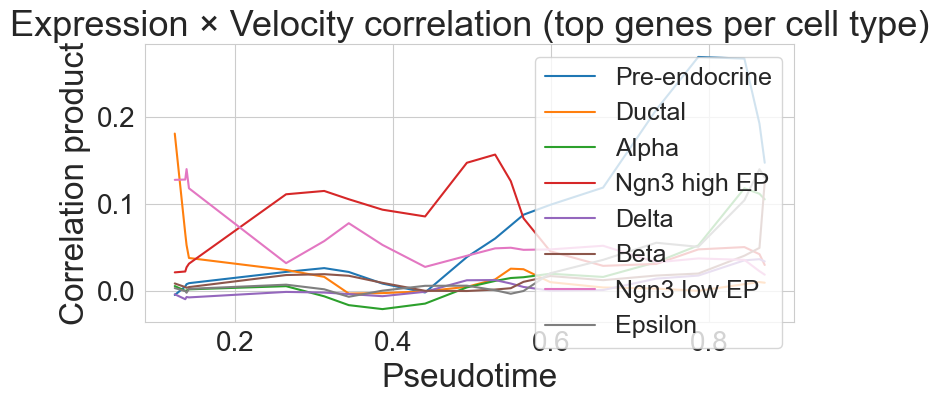

In [36]:
fig, ax = plt.subplots(
    1, 1,
    figsize=(8.0, 4.5)
)

for ct in cell_types:

    if ct not in top_genes_by_cell_type:
        continue

    top_idx = top_genes_by_cell_type[ct]

    # --- average over genes first ---
    expr_curve = np.nanmean(expr_corr_traces[:, top_idx], axis=1)
    vel_curve  = np.nanmean(vel_corr_traces[:, top_idx], axis=1)

    # --- product ---
    prod_curve = expr_curve * vel_curve

    ax.plot(pt_centers, prod_curve, label=ct)

# --- labels ---
ax.set_title("Expression × Velocity correlation (top genes per cell type)")
ax.set_xlabel("Pseudotime")
ax.set_ylabel("Correlation product")

ax.legend()

plt.tight_layout()
plt.show()

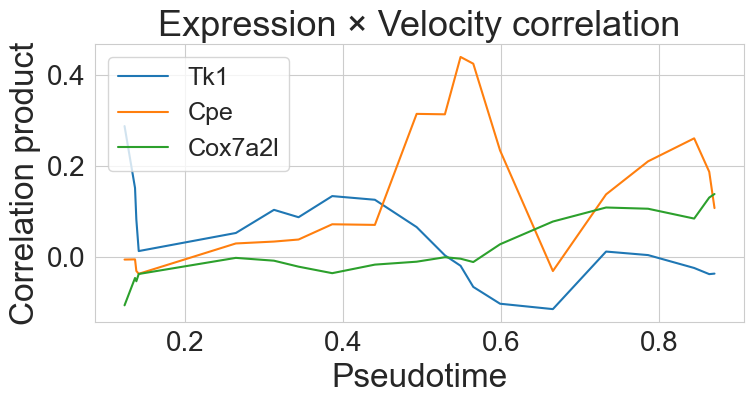

In [37]:
gene_list = ["Tk1", "Cpe", "Cox7a2l"]

fig, ax = plt.subplots(
    1, 1,
    figsize=(8.0, 4.5)
)

# --- map gene names to indices ---
gene_names = adata.var_names.to_numpy()
gene_to_idx = {g: i for i, g in enumerate(gene_names)}

for gene in gene_list:

    if gene not in gene_to_idx:
        print(f"[Skip] {gene} not found")
        continue

    g_idx = gene_to_idx[gene]

    expr_curve = np.nan_to_num(expr_corr_traces[:, g_idx], nan=0.0)
    vel_curve  = np.nan_to_num(vel_corr_traces[:, g_idx],  nan=0.0)

    # --- product ---
    prod_curve = expr_curve * vel_curve

    ax.plot(pt_centers, prod_curve, label=gene)

# --- labels ---
ax.set_title("Expression × Velocity correlation")
ax.set_xlabel("Pseudotime")
ax.set_ylabel("Correlation product")

ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.cluster.hierarchy import linkage, leaves_list

# ------------------------------------------------------------
# 1. Build FULL score tables
# ------------------------------------------------------------
full_scores = {}

for ct, res_dict in results_by_cell_type.items():
    res = res_dict["eval"]

    expr = np.asarray(res["expr_corr_gene"])
    vel  = np.asarray(res["vel_corr_gene"])
    genes = np.asarray(adata.var.index)

    mask = np.isfinite(expr) & np.isfinite(vel)

    df_ct = pd.DataFrame({
        "gene": genes[mask],
        "score": (expr * vel)[mask]
    }).set_index("gene")

    full_scores[ct] = df_ct


# ------------------------------------------------------------
# 2. Select top genes
# ------------------------------------------------------------
top_k = 10
all_top_genes = set()

for ct, df_ct in full_scores.items():
    top_genes = df_ct["score"].nlargest(top_k).index
    all_top_genes.update(top_genes)

all_top_genes = sorted(all_top_genes)


# ------------------------------------------------------------
# 3. Build dense matrix
# ------------------------------------------------------------
heatmap_df = pd.DataFrame(
    index=results_by_cell_type.keys(),
    columns=all_top_genes,
    dtype=float
)

for ct, df_ct in full_scores.items():
    heatmap_df.loc[ct] = df_ct.reindex(all_top_genes)["score"].values

# ✅ FIX 1: fill NaNs with 0
heatmap_df = heatmap_df.fillna(0)


# ------------------------------------------------------------
# 4. Reorder cell types
# ------------------------------------------------------------
cell_type_order = [
    "Ductal",
    "Ngn3 low EP",
    "Ngn3 high EP",
    "Pre-endocrine",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]

cell_type_order = [ct for ct in cell_type_order if ct in heatmap_df.index]
heatmap_df = heatmap_df.loc[cell_type_order]


# ------------------------------------------------------------
# 5. Clip values
# ------------------------------------------------------------
heatmap_df_clipped = heatmap_df.clip(lower=-0.4, upper=0.4)


# # ------------------------------------------------------------
# # 6. Cluster genes
# # ------------------------------------------------------------
# col_linkage = linkage(
#     heatmap_df_clipped.T,
#     method="average",
#     metric="euclidean"
# )

# col_order = leaves_list(col_linkage)
# heatmap_df_clipped = heatmap_df_clipped.iloc[:, col_order]

# ------------------------------------------------------------
# 6. Order genes by cell-type-specific ranking
# ------------------------------------------------------------
ordered_genes = []

for ct in cell_type_order:
    if ct not in full_scores:
        continue

    df_ct = full_scores[ct]

    # take top_k genes in descending score
    top_genes_ct = df_ct["score"].nlargest(top_k).index.tolist()

    ordered_genes.extend(top_genes_ct)

# --- remove duplicates while preserving order ---
seen = set()
ordered_genes = [g for g in ordered_genes if not (g in seen or seen.add(g))]

# --- reorder columns ---
heatmap_df_clipped = heatmap_df_clipped[ordered_genes]

# ------------------------------------------------------------
# 7. Plot heatmap
# ------------------------------------------------------------
fig_width = 12
fig_height = 3.5

plt.figure(figsize=(fig_width, fig_height))

cmap = sns.light_palette("red", as_cmap=True)

ax = sns.heatmap(
    heatmap_df_clipped,
    cmap=cmap,
    vmin=0.0,
    vmax=0.4,
    cbar=False,
    linewidths=0
)

# ----------------------------
# Clean aesthetics
# ----------------------------
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks(np.arange(len(heatmap_df_clipped.columns)) + 0.5)

ax.set_xticklabels(
    heatmap_df_clipped.columns,
    rotation=90,
    fontsize=11  # ↓ smaller to fit more
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=15
)

ax.tick_params(length=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()

# ------------------------------------------------------------
# 8. Save figure
# ------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "gene_concordance_heatmap.png")

plt.savefig(save_path, bbox_inches="tight", dpi=300)

print("Saved to:", save_path)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.sparse import issparse

# ------------------------------------------------------------
# 1. Build FULL expression tables
# ------------------------------------------------------------
full_expr = {}

genes = np.asarray(adata.var.index)

for ct, res_dict in results_by_cell_type.items():

    # --------------------------------------------------------
    # Cell mask
    # --------------------------------------------------------
    mask_ct = adata.obs["clusters"] == ct

    X = adata[mask_ct].X

    if issparse(X):
        X = X.toarray()

    # --------------------------------------------------------
    # Mean expression per gene
    # --------------------------------------------------------
    mean_expr = np.asarray(X.mean(axis=0)).ravel()

    df_ct = pd.DataFrame({
        "gene": genes,
        "expr": mean_expr
    }).set_index("gene")

    full_expr[ct] = df_ct


# ------------------------------------------------------------
# 2. Select top genes using concordance score
# ------------------------------------------------------------
top_k = 10
all_top_genes = set()

for ct, res_dict in results_by_cell_type.items():

    res = res_dict["eval"]

    expr_corr = np.asarray(res["expr_corr_gene"])
    vel_corr  = np.asarray(res["vel_corr_gene"])

    mask = np.isfinite(expr_corr) & np.isfinite(vel_corr)

    score_df = pd.DataFrame({
        "gene": genes[mask],
        "score": (expr_corr * vel_corr)[mask]
    }).set_index("gene")

    top_genes = score_df["score"].nlargest(top_k).index

    all_top_genes.update(top_genes)

all_top_genes = sorted(all_top_genes)


# ------------------------------------------------------------
# 3. Build dense expression matrix
# ------------------------------------------------------------
heatmap_df = pd.DataFrame(
    index=results_by_cell_type.keys(),
    columns=all_top_genes,
    dtype=float
)

for ct, df_ct in full_expr.items():

    heatmap_df.loc[ct] = (
        df_ct.reindex(all_top_genes)["expr"].values
    )

heatmap_df = heatmap_df.fillna(0)


# ------------------------------------------------------------
# 4. Reorder cell types
# ------------------------------------------------------------
cell_type_order = [
    "Ductal",
    "Ngn3 low EP",
    "Ngn3 high EP",
    "Pre-endocrine",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]

cell_type_order = [
    ct for ct in cell_type_order
    if ct in heatmap_df.index
]

heatmap_df = heatmap_df.loc[cell_type_order]


# ------------------------------------------------------------
# 5. Log transform + per-gene normalization
# ------------------------------------------------------------
heatmap_df = np.log1p(heatmap_df)

# per-gene z-score
heatmap_df_z = (
    heatmap_df - heatmap_df.mean(axis=0)
) / (
    heatmap_df.std(axis=0) + 1e-8
)

# clip for visualization stability
heatmap_df_clipped = heatmap_df_z.clip(
    lower=-2,
    upper=2
)

# ------------------------------------------------------------
# 6. Order genes by concordance ranking
# ------------------------------------------------------------
ordered_genes = []

for ct in cell_type_order:

    if ct not in results_by_cell_type:
        continue

    res = results_by_cell_type[ct]["eval"]

    expr_corr = np.asarray(res["expr_corr_gene"])
    vel_corr  = np.asarray(res["vel_corr_gene"])

    mask = np.isfinite(expr_corr) & np.isfinite(vel_corr)

    score_df = pd.DataFrame({
        "gene": genes[mask],
        "score": (expr_corr * vel_corr)[mask]
    }).set_index("gene")

    top_genes_ct = (
        score_df["score"]
        .nlargest(top_k)
        .index
        .tolist()
    )

    ordered_genes.extend(top_genes_ct)

# remove duplicates while preserving order
seen = set()

ordered_genes = [
    g for g in ordered_genes
    if not (g in seen or seen.add(g))
]

heatmap_df_clipped = heatmap_df_clipped[ordered_genes]


# ------------------------------------------------------------
# 7. Plot heatmap
# ------------------------------------------------------------
fig_width = 12
fig_height = 3.5

plt.figure(figsize=(fig_width, fig_height))

cmap = sns.light_palette(
    "#d62728",
    as_cmap=True
)

ax = sns.heatmap(
    heatmap_df_clipped,
    cmap=cmap,
    vmin=-2,
    vmax=2,
    center=0,
    cbar=False,
    linewidths=0
)

# ------------------------------------------------------------
# Aesthetics
# ------------------------------------------------------------
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticks(
    np.arange(len(heatmap_df_clipped.columns)) + 0.5
)

ax.set_xticklabels(
    heatmap_df_clipped.columns,
    rotation=90,
    fontsize=11
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=15
)

ax.tick_params(length=0)

sns.despine(
    left=True,
    bottom=True
)

plt.tight_layout()


# ------------------------------------------------------------
# 8. Save figure
# ------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "gene_expression_heatmap.png"
)

plt.savefig(
    save_path,
    bbox_inches="tight",
    dpi=300
)

print("Saved to:", save_path)

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.sparse import issparse

# ============================================================
# SETTINGS
# ============================================================
top_k = 10

cell_type_order = [
    "Ductal",
    "Ngn3 low EP",
    "Ngn3 high EP",
    "Pre-endocrine",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# COMMON GENE ORDER
# ============================================================
genes = np.asarray(adata.var.index)

# ------------------------------------------------------------
# Build concordance score tables
# ------------------------------------------------------------
full_scores = {}

for ct, res_dict in results_by_cell_type.items():

    res = res_dict["eval"]

    expr_corr = np.asarray(res["expr_corr_gene"])
    vel_corr  = np.asarray(res["vel_corr_gene"])

    mask = np.isfinite(expr_corr) & np.isfinite(vel_corr)

    df_ct = pd.DataFrame({
        "gene": genes[mask],
        "score": (expr_corr * vel_corr)[mask]
    }).set_index("gene")

    full_scores[ct] = df_ct

# ------------------------------------------------------------
# Global top genes
# ------------------------------------------------------------
all_top_genes = set()

for ct, df_ct in full_scores.items():

    top_genes = (
        df_ct["score"]
        .nlargest(top_k)
        .index
    )

    all_top_genes.update(top_genes)

all_top_genes = sorted(all_top_genes)

# ============================================================
# HEATMAP 1:
# Concordance score heatmap
# ============================================================
score_df = pd.DataFrame(
    index=results_by_cell_type.keys(),
    columns=all_top_genes,
    dtype=float
)

for ct, df_ct in full_scores.items():

    score_df.loc[ct] = (
        df_ct.reindex(all_top_genes)["score"].values
    )

score_df = score_df.fillna(0)

# reorder rows
cell_type_order_filtered = [
    ct for ct in cell_type_order
    if ct in score_df.index
]

score_df = score_df.loc[cell_type_order_filtered]

# clip
score_df = score_df.clip(
    lower=0.0,
    upper=0.4
)

# ============================================================
# HEATMAP 2:
# Expression heatmap
# ============================================================
full_expr = {}

for ct, res_dict in results_by_cell_type.items():

    mask_ct = adata.obs["clusters"] == ct

    X = adata[mask_ct].X

    if issparse(X):
        X = X.toarray()

    mean_expr = np.asarray(
        X.mean(axis=0)
    ).ravel()

    df_ct = pd.DataFrame({
        "gene": genes,
        "expr": mean_expr
    }).set_index("gene")

    full_expr[ct] = df_ct

expr_df = pd.DataFrame(
    index=results_by_cell_type.keys(),
    columns=all_top_genes,
    dtype=float
)

for ct, df_ct in full_expr.items():

    expr_df.loc[ct] = (
        df_ct.reindex(all_top_genes)["expr"].values
    )

expr_df = expr_df.fillna(0)

expr_df = expr_df.loc[cell_type_order_filtered]

# ------------------------------------------------------------
# Log transform + z-score
# ------------------------------------------------------------
expr_df = np.log1p(expr_df)

expr_df = (
    expr_df - expr_df.mean(axis=0)
) / (
    expr_df.std(axis=0) + 1e-8
)

expr_df = expr_df.clip(
    lower=-2,
    upper=2
)

# ============================================================
# ORDER GENES BY CELL-TYPE RANKING
# ============================================================
ordered_genes = []

for ct in cell_type_order_filtered:

    if ct not in full_scores:
        continue

    top_genes_ct = (
        full_scores[ct]["score"]
        .nlargest(top_k)
        .index
        .tolist()
    )

    ordered_genes.extend(top_genes_ct)

# remove duplicates while preserving order
seen = set()

ordered_genes = [
    g for g in ordered_genes
    if not (g in seen or seen.add(g))
]

# reorder columns
score_df = score_df[ordered_genes]
expr_df  = expr_df[ordered_genes]

# ============================================================
# PLOT STACKED HEATMAPS
# ============================================================
fig = plt.figure(figsize=(18, 7))

# ------------------------------------------------------------
# LARGER GAP BETWEEN HEATMAPS
# ------------------------------------------------------------
gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[1, 1],
    hspace=0.2
)

# ============================================================
# TOP: concordance scores
# ============================================================
ax1 = fig.add_subplot(gs[0])

cmap_score = sns.light_palette(
    "red",
    as_cmap=True
)

sns.heatmap(
    score_df,
    ax=ax1,
    cmap=cmap_score,
    vmin=0,
    vmax=0.4,
    cbar=False,
    linewidths=0
)

ax1.set_xlabel("")
ax1.set_ylabel("")

# hide x labels on top panel
ax1.set_xticklabels([])

# ------------------------------------------------------------
# FORCE ALL CELL TYPE LABELS
# ------------------------------------------------------------
y_positions = np.arange(len(score_df.index)) + 0.5

ax1.set_yticks(y_positions)
ax1.set_yticklabels(
    score_df.index,
    rotation=0,
    fontsize=13
)

ax1.tick_params(length=0)

sns.despine(
    ax=ax1,
    left=True,
    bottom=True
)

# ============================================================
# BOTTOM: expression
# ============================================================
ax2 = fig.add_subplot(gs[1])

from matplotlib.colors import LinearSegmentedColormap

cmap_expr = plt.cm.inferno
sns.heatmap(
    expr_df,
    ax=ax2,
    cmap=cmap_expr,
    vmin=-2,
    vmax=2,
    center=0,
    cbar=False,
    linewidths=0
)

ax2.set_xlabel("")
ax2.set_ylabel("")

# ------------------------------------------------------------
# X labels
# ------------------------------------------------------------
ax2.set_xticks(
    np.arange(len(expr_df.columns)) + 0.5
)

ax2.set_xticklabels(
    expr_df.columns,
    rotation=90,
    fontsize=14
)

# ------------------------------------------------------------
# FORCE ALL CELL TYPE LABELS
# ------------------------------------------------------------
ax2.set_yticks(y_positions)
ax2.set_yticklabels(
    expr_df.index,
    rotation=0,
    fontsize=16
)

ax2.tick_params(length=0)

sns.despine(
    ax=ax2,
    left=True,
    bottom=True
)

# ============================================================
# SAVE
# ============================================================
plt.tight_layout()

save_path = os.path.join(
    save_dir,
    "stacked_gene_heatmaps.png"
)

plt.savefig(
    save_path,
    bbox_inches="tight",
    dpi=300
)

print("Saved to:", save_path)

plt.show()

In [ ]:
# ============================================================
# THIN VERTICAL COLORBAR:
# Correlation product
# ============================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(0.18, 3.0))

cmap_score = sns.light_palette(
    "red",
    as_cmap=True
)

norm = mpl.colors.Normalize(
    vmin=0.0,
    vmax=0.4
)

cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=cmap_score,
    norm=norm,
    orientation="vertical",
    ticks=[0.0, 0.2, 0.4]
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------
# cb.set_label(
#     r"$\mathrm{cor(expression)} \times \mathrm{cor(velocity)}$",
#     fontsize=12,
#     rotation=90,
#     labelpad=14
# )

cb.ax.tick_params(
    labelsize=16,
    length=2
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_path = os.path.join(
    save_dir,
    "colorbar_concordance_vertical.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

print("Saved:", save_path)

plt.show()

In [ ]:
# ============================================================
# ULTRA-THIN VERTICAL COLORBAR:
# Gene expression z-score (inferno)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(0.18, 3.0))

# inferno colormap
cmap_expr = plt.cm.inferno

norm = mpl.colors.Normalize(
    vmin=-2,
    vmax=2
)

cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=cmap_expr,
    norm=norm,
    orientation="vertical",
    ticks=[-2, -1, 0, 1, 2]
)

# ------------------------------------------------------------
# Remove boundary / outline
# ------------------------------------------------------------
cb.outline.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------
# Tick styling
# ------------------------------------------------------------
cb.ax.tick_params(
    labelsize=16,
    length=2,
    width=0.8
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_path = os.path.join(
    save_dir,
    "colorbar_expression_inferno_vertical.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

print("Saved:", save_path)

plt.show()

In [46]:
from upsetplot import from_contents, UpSet
import matplotlib.pyplot as plt
import numpy as np

threshold = 0.2
gene_sets = {}

for ct, res_dict in results_by_cell_type.items():

    res = res_dict["eval"]

    expr = np.asarray(res["expr_corr_gene"])
    vel  = np.asarray(res["vel_corr_gene"])
    genes = np.asarray(adata.var_names)

    mask = (
        (expr > threshold) &
        (vel > threshold) &
        np.isfinite(expr) &
        np.isfinite(vel)
    )

    gene_sets[ct] = set(genes[mask])

    print(f"{ct}: {len(gene_sets[ct])} signature genes")

Pre-endocrine: 159 signature genes
Ductal: 61 signature genes
Alpha: 36 signature genes
Ngn3 high EP: 288 signature genes
Delta: 113 signature genes
Beta: 46 signature genes
Ngn3 low EP: 74 signature genes
Epsilon: 214 signature genes


In [47]:
merged_groups = {
    "Progenitor": ["Ductal", "Ngn3 low EP"],
    "Endocrine progenitor": ["Ngn3 high EP", "Pre-endocrine"],
    "Alpha": ["Alpha"],
    "Beta": ["Beta"],
    "Delta": ["Delta"],
    "Epsilon": ["Epsilon"],
}

# preserve order explicitly
ordered_keys = list(merged_groups.keys())

merged_gene_sets = {}
for k in ordered_keys:
    merged_set = set()
    for ct in merged_groups[k]:
        if ct in gene_sets:
            merged_set |= gene_sets[ct]
    merged_gene_sets[k] = merged_set

In [51]:
colmap = dict(zip(categories, colors))

group_color_map = {
    "Progenitor": colmap["Ductal"],
    "Endocrine progenitor": colmap["Pre-endocrine"],
    "Alpha": colmap["Alpha"],
    "Beta": colmap["Beta"],
    "Delta": colmap["Delta"],
    "Epsilon": colmap["Epsilon"],
}

# ------------------------------------------------------------
# Define x positions and bar colors
# ------------------------------------------------------------
x = np.arange(len(intersection_counts))

bar_colors = []

for _, row in intersection_counts.iterrows():

    active_groups = [
        g for g in groups if row[g]
    ]

    # singleton intersections
    if len(active_groups) == 1:
        bar_colors.append(
            group_color_map[active_groups[0]]
        )

    # multi-group intersections
    else:
        bar_colors.append("black")

# ------------------------------------------------------------
# Shared max count for consistent axes
# ------------------------------------------------------------
max_count = max(
    max(row_totals := [len(merged_gene_sets[g]) for g in groups]),
    intersection_counts["count"].max()
)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define ordered groups (TOP → BOTTOM)
# ------------------------------------------------------------
groups = [
    "Progenitor",
    "Endocrine progenitor",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]

# ------------------------------------------------------------
# 2. Build membership matrix
# ------------------------------------------------------------
all_genes = set().union(*merged_gene_sets.values())

data = []
for gene in all_genes:
    membership = [gene in merged_gene_sets[g] for g in groups]
    data.append(membership)

df = pd.DataFrame(data, columns=groups)

# ------------------------------------------------------------
# 3. Compute intersections
# ------------------------------------------------------------
intersection_counts = (
    df.groupby(groups)
    .size()
    .reset_index(name="count")
)

intersection_counts["degree"] = intersection_counts[groups].sum(axis=1)

# ------------------------------------------------------------
# 3.5 Filter small intersections
# ------------------------------------------------------------
min_count = 3
intersection_counts = intersection_counts[
    intersection_counts["count"] > min_count
].copy()

# ------------------------------------------------------------
# 4. Custom column ordering
# ------------------------------------------------------------
singletons = intersection_counts[intersection_counts["degree"] == 1].copy()

def singleton_order(row):
    for i, g in enumerate(groups):
        if row[g]:
            return i
    return 999

singletons["order"] = singletons.apply(singleton_order, axis=1)
singletons = singletons.sort_values("order")

multi = intersection_counts[intersection_counts["degree"] > 1].copy()
multi = multi.sort_values(by=["degree", "count"], ascending=[True, False])

intersection_counts = pd.concat([singletons, multi], ignore_index=True)

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
fig = plt.figure(figsize=(11, 6))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[2, 2],
    width_ratios=[4, 1],
    wspace=0.05
)

# axes (correct placement)
ax_bar   = fig.add_subplot(gs[0, 0])
ax_mat   = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

# ----------------------------
# Top: bar plot
# ----------------------------

ax_bar.bar(x, intersection_counts["count"], color=bar_colors)

# --- show y-axis ---
# ax_bar.set_ylabel("# genes", fontsize=10)

# reference ticks
yticks = [100, 200]
ax_bar.set_yticks(yticks)
ax_bar.tick_params(axis="y", labelsize=16)
# gridlines for readability
ax_bar.yaxis.grid(True, linestyle="--", alpha=0.4)

# enforce shared scale
ax_bar.set_ylim(0, intersection_counts["count"].max() * 1.1)

# keep x clean
ax_bar.set_xticks([])
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# ----------------------------
# Bottom: dot matrix
# ----------------------------
for i, row in intersection_counts.iterrows():
    for j, g in enumerate(groups):
        if row[g]:
            ax_mat.scatter(i, j, color=group_color_map[g], s=160)
        else:
            ax_mat.scatter(i, j, color="lightgrey", s=80, alpha=0.5)

# ----------------------------
# Right: group totals
# ----------------------------
row_totals = [len(merged_gene_sets[g]) for g in groups]
y_pos = np.arange(len(groups))

ax_right.barh(
    y_pos,
    row_totals,
    color=[group_color_map[g] for g in groups]
)

# shared scale
ax_right.set_xlim(0, max_count)

# show same reference ticks
ax_right.set_xticks(yticks)
ax_right.tick_params(axis="x", labelsize=16)
# gridlines
ax_right.xaxis.grid(True, linestyle="--", alpha=0.4)

# clean up
# ax_right.set_xlabel("# genes", fontsize=10)
ax_right.set_yticks([])
ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)

V = adata.layers["velocity"]  # (cells × genes)
vel_mag = np.sqrt((V ** 2).sum(axis=1))

cluster_key = "clusters"

vel_by_ct = {}

for ct in adata.obs[cluster_key].cat.categories:
    idx = adata.obs[cluster_key] == ct
    vel_by_ct[ct] = vel_mag[idx].mean()

vel_by_group = {}

for g, ct_list in merged_groups.items():
    vals = [vel_by_ct[ct] for ct in ct_list if ct in vel_by_ct]
    vel_by_group[g] = np.mean(vals)

# normalize for plotting (optional but recommended)
vals = np.array([vel_by_group[g] for g in groups])
vals_norm = vals / vals.max()

# scale to match bar width
max_bar = max(row_totals)

x_pos = vals_norm * max_bar

y_pos = np.arange(len(groups))

# ax_right.scatter(
#     x_pos,
#     y_pos,
#     color="black",
#     s=50,
#     zorder=3
# )

# ----------------------------
# formatting
# ----------------------------
ax_mat.set_yticks(range(len(groups)))
ax_mat.set_yticklabels(groups)
ax_mat.invert_yaxis()

ax_mat.set_xticks([])
ax_mat.spines[:].set_visible(False)

plt.tight_layout()

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "celltype_upside.png")

plt.savefig(save_path, bbox_inches="tight", dpi=300)

plt.show()

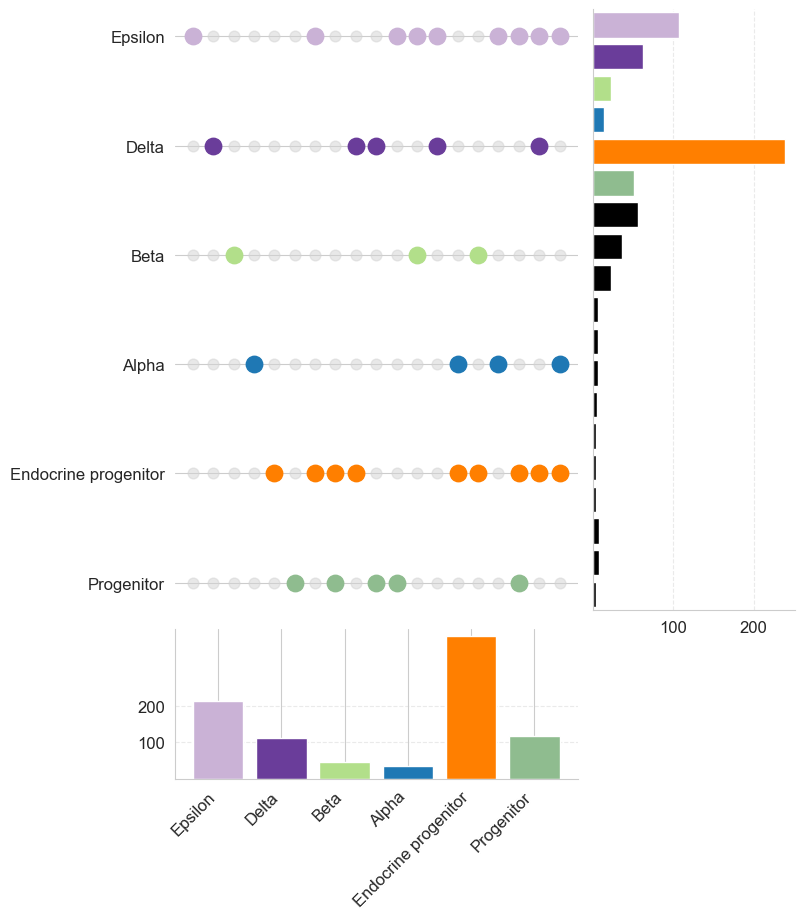

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define ordered groups (TOP → BOTTOM)
# ------------------------------------------------------------
groups = [
    "Progenitor",
    "Endocrine progenitor",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]
groups = groups[::-1]
# ------------------------------------------------------------
# 2. Build membership matrix
# ------------------------------------------------------------
all_genes = set().union(*merged_gene_sets.values())

data = []
for gene in all_genes:
    membership = [gene in merged_gene_sets[g] for g in groups]
    data.append(membership)

df = pd.DataFrame(data, columns=groups)

# ------------------------------------------------------------
# 3. Compute intersections
# ------------------------------------------------------------
intersection_counts = (
    df.groupby(groups)
    .size()
    .reset_index(name="count")
)

intersection_counts["degree"] = intersection_counts[groups].sum(axis=1)

# ------------------------------------------------------------
# 3.5 Filter small intersections
# ------------------------------------------------------------
min_count = 3
intersection_counts = intersection_counts[
    intersection_counts["count"] > min_count
].copy()

# ------------------------------------------------------------
# 4. Custom column ordering
# ------------------------------------------------------------
singletons = intersection_counts[intersection_counts["degree"] == 1].copy()

def singleton_order(row):
    for i, g in enumerate(groups):
        if row[g]:
            return i
    return 999

singletons["order"] = singletons.apply(singleton_order, axis=1)
singletons = singletons.sort_values("order")

multi = intersection_counts[intersection_counts["degree"] > 1].copy()
multi = multi.sort_values(by=["degree", "count"], ascending=[True, False])

intersection_counts = pd.concat([singletons, multi], ignore_index=True)

# ------------------------------------------------------------
# 5. Plot (ROTATED LAYOUT)
# ------------------------------------------------------------
fig = plt.figure(figsize=(8, 10))
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[4, 1],
    width_ratios=[4, 2],
    hspace=0.05,
    wspace=0.05
)

ax_mat   = fig.add_subplot(gs[0, 0])  # main matrix
ax_bar   = fig.add_subplot(gs[0, 1])  # right (intersection bars)
ax_bottom = fig.add_subplot(gs[1, 0]) # bottom (group totals)

x = np.arange(len(intersection_counts))

# ----------------------------
# RIGHT: intersection bars (vertical)
# ----------------------------
ax_bar.barh(x, intersection_counts["count"], color=bar_colors)

ax_bar.set_yticks([])
ax_bar.set_xticks([100, 200])
ax_bar.tick_params(labelsize=12)

ax_bar.xaxis.grid(True, linestyle="--", alpha=0.4)

ax_bar.set_ylim(-0.5, len(x) - 0.5)
ax_bar.invert_yaxis()

ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# ----------------------------
# CENTER: dot matrix
# ----------------------------
for i, row in intersection_counts.iterrows():
    for j, g in enumerate(groups):
        if row[g]:
            ax_mat.scatter(i, j, color=group_color_map[g], s=140)
        else:
            ax_mat.scatter(i, j, color="lightgrey", s=60, alpha=0.5)

ax_mat.set_yticks(range(len(groups)))
ax_mat.set_yticklabels(groups, fontsize=12)

ax_mat.set_xticks([])
ax_mat.invert_yaxis()
ax_mat.spines[:].set_visible(False)

# ----------------------------
# BOTTOM: group totals
# ----------------------------
row_totals = [len(merged_gene_sets[g]) for g in groups]
x_groups = np.arange(len(groups))

ax_bottom.bar(
    x_groups,
    row_totals,
    color=[group_color_map[g] for g in groups]
)

ax_bottom.set_xticks(x_groups)
ax_bottom.set_xticklabels(groups, rotation=45, ha="right", fontsize=12)

ax_bottom.set_yticks([100, 200])
ax_bottom.tick_params(labelsize=12)

ax_bottom.yaxis.grid(True, linestyle="--", alpha=0.4)

ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
from flowmap.evaluation import SplineFitEvaluator
import numpy as np

# ============================================================
# Evaluate by cell type using PC-level splines
# ============================================================
cell_types = adata.obs["clusters"].unique().tolist()

results_by_cell_type = {}

for ct in cell_types:

    print(f"\n=== Evaluating cell type: {ct} ===")

    # --------------------------------------------------------
    # Cell subset
    # --------------------------------------------------------
    cell_idx = np.where(
        adata.obs["clusters"].values == ct
    )[0]

    if len(cell_idx) < 10:
        print(f"[Skip] Too few cells ({len(cell_idx)})")
        continue

    # --------------------------------------------------------
    # Evaluate PC-level reconstruction
    # --------------------------------------------------------
    evaluator = SplineFitEvaluator(
        emb,
        mode="default"
    )

    res = evaluator.evaluate(
        cell_idx=cell_idx
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    results_by_cell_type[ct] = {
        "n_cells": len(cell_idx),
        "eval": res,
    }

    # --------------------------------------------------------
    # Summary statistics
    # --------------------------------------------------------
    expr_corr = np.asarray(
        res["expr_corr_gene"]
    )

    vel_corr = np.asarray(
        res["vel_corr_gene"]
    )

    mean_expr = np.nanmean(expr_corr)
    mean_vel  = np.nanmean(vel_corr)

    print(
        f"[{ct}] "
        f"expr_corr={mean_expr:.3f} | "
        f"vel_corr={mean_vel:.3f}"
    )

print("\nPC-level evaluation complete.")


=== Evaluating cell type: Pre-endocrine ===
[Pre-endocrine] expr_corr=0.312 | vel_corr=0.726

=== Evaluating cell type: Ductal ===
[Ductal] expr_corr=0.379 | vel_corr=0.666

=== Evaluating cell type: Alpha ===
[Alpha] expr_corr=0.272 | vel_corr=0.438

=== Evaluating cell type: Ngn3 high EP ===
[Ngn3 high EP] expr_corr=0.349 | vel_corr=0.732

=== Evaluating cell type: Delta ===
[Delta] expr_corr=0.203 | vel_corr=0.381

=== Evaluating cell type: Beta ===
[Beta] expr_corr=0.259 | vel_corr=0.584

=== Evaluating cell type: Ngn3 low EP ===
[Ngn3 low EP] expr_corr=0.338 | vel_corr=0.725

=== Evaluating cell type: Epsilon ===
[Epsilon] expr_corr=0.251 | vel_corr=0.627

PC-level evaluation complete.


In [ ]:
import math
import os
from adjustText import adjust_text

# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
cell_types = list(results_by_cell_type.keys())
n_ct = len(cell_types)

n_pcs = 50
pcs_all = np.array([f"PC{i}" for i in range(1, n_pcs + 1)])
top_pcs = {f"PC{i}" for i in range(1, 11)}

# grid layout
ncols = 3
nrows = math.ceil(n_ct / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 5 * nrows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

# ------------------------------------------------------------
# Loop over cell types
# ------------------------------------------------------------
for ax, ct in zip(axes, cell_types):

    res = results_by_cell_type[ct]["eval"]

    # --------------------------------------------------------
    # USE PC-LEVEL CORRELATIONS
    # --------------------------------------------------------
    expr_corr = np.array(res["expr_corr_gene"])
    vel_corr  = np.array(res["vel_corr_gene"])

    valid = np.isfinite(expr_corr) & np.isfinite(vel_corr)

    pcs = pcs_all[valid]
    expr_corr = expr_corr[valid]
    vel_corr  = vel_corr[valid]

    is_top = np.array([pc in top_pcs for pc in pcs])

    # background PCs
    ax.scatter(
        expr_corr[~is_top],
        vel_corr[~is_top],
        s=70,
        color="grey",
        alpha=0.6,
        edgecolor="none",
        zorder=1
    )

    # highlighted PCs
    ax.scatter(
        expr_corr[is_top],
        vel_corr[is_top],
        s=180,
        color="steelblue",
        alpha=0.7,
        lw=0.8,
        zorder=3
    )

    # labels for top PCs
    texts = []
    for x, y, pc in zip(expr_corr[is_top], vel_corr[is_top], pcs[is_top]):
        texts.append(
            ax.text(
                x, y, pc,
                fontsize=11,
                weight="bold",
                ha="left",
                va="bottom"
            )
        )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", lw=0.9, color="black"),
        force_text=1.2,
        force_points=1.0,
        expand_text=(1.2, 1.2),
        expand_points=(1.2, 1.2),
    )

    ax.set_title(ct, fontsize=16)
    ax.set_xlim(0, 1.1)
    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle="--", alpha=0.4)

# ------------------------------------------------------------
# Remove empty panels
# ------------------------------------------------------------
for ax in axes[len(cell_types):]:
    ax.axis("off")

# ------------------------------------------------------------
# Shared labels
# ------------------------------------------------------------
fig.text(
    0.5, 0.04,
    r"Expression concordance $(r)$",
    ha="center",
    fontsize=18
)
fig.text(
    0.04, 0.5,
    r"Velocity concordance $(r)$",
    va="center",
    rotation="vertical",
    fontsize=18
)

plt.tight_layout(rect=[0.06, 0.06, 1, 1])

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
outdir = str(FIGURE_DIR)
os.makedirs(outdir, exist_ok=True)

plt.savefig(
    os.path.join(outdir, "pc_concordance_by_cell_type.png"),
    dpi=200
)
plt.show()
plt.close()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------------
# Context: PCA space
# ------------------------------------------------------------------
X_pca = adata.obsm["X_pca"]
V_pca = adata.obsm["stochastic_velocity_pca"]

n_pcs = 10   # show PC1–PC10 in the heatmap
pcs = [f"PC{i}" for i in range(1, n_pcs + 1)]
cell_types = list(results_by_cell_type.keys())

# --- colormap: white -> red (R^2 style) ----------------------------
cmap_r2 = LinearSegmentedColormap.from_list(
    "white_red",
    ["#ffffff", "#fddede", "#f46d6d", "#b30000"]
)

# ------------------------------------------------------------------
# Collect PC-level reconstruction R^2
# ------------------------------------------------------------------
expr_pca_rows = []
vel_pca_rows  = []

for ct in cell_types:
    res = results_by_cell_type[ct]["eval"]

    expr_corr = np.asarray(res["expr_corr_gene"])  # length >= n_pcs
    vel_corr  = np.asarray(res["vel_corr_gene"])

    row_expr = {f"PC{i+1}": expr_corr[i] for i in range(n_pcs)}
    row_vel  = {f"PC{i+1}": vel_corr[i]  for i in range(n_pcs)}

    expr_pca_rows.append(pd.Series(row_expr, name=ct))
    vel_pca_rows.append(pd.Series(row_vel,  name=ct))

expr_pca_df = pd.DataFrame(expr_pca_rows)
vel_pca_df  = pd.DataFrame(vel_pca_rows)

# ------------------------------------------------------------------
# Cell-type ordering (paper order)
# ------------------------------------------------------------------
cell_type_order = [
    "Ductal",
    "Ngn3 low EP",
    "Ngn3 high EP",
    "Pre-endocrine",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]

expr_pca_df = expr_pca_df.reindex(cell_type_order)
vel_pca_df  = vel_pca_df.reindex(cell_type_order)

# ------------------------------------------------------------------
# Annotation formatting (no leading zero)
# ------------------------------------------------------------------
def fmt_no_leading_zero(x):
    if np.isnan(x):
        return ""
    s = f"{x:.2f}"
    return s[1:] if s.startswith("0") else s

expr_pca_annot = expr_pca_df.applymap(fmt_no_leading_zero)
vel_pca_annot  = vel_pca_df.applymap(fmt_no_leading_zero)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(1.2 * len(pcs) + 6, 0.55 * len(cell_type_order)),
    sharey=True
)

sns.heatmap(
    expr_pca_df,
    ax=axes[0],
    cmap=cmap_r2,
    vmin=0.4, vmax=1,
    linewidths=0.4,
    cbar=False,
    annot=expr_pca_annot,
    fmt="",
    annot_kws={"fontsize": 14}
)

sns.heatmap(
    vel_pca_df,
    ax=axes[1],
    cmap=cmap_r2,
    vmin=0.4, vmax=1,
    linewidths=0.4,
    cbar=False,
    annot=vel_pca_annot,
    fmt="",
    annot_kws={"fontsize": 14}
)

# ------------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------------
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])

sm = plt.cm.ScalarMappable(
    cmap=cmap_r2,
    norm=plt.Normalize(vmin=0.4, vmax=1)
)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_ticks([0.4, 0.7, 1.0])
cbar.set_ticklabels(["0.4", "0.7", "1.0"])
cbar.ax.tick_params(labelsize=18)

# ------------------------------------------------------------------
# Axes cosmetics
# ------------------------------------------------------------------
for ax in axes:
    ax.tick_params(axis="x", labelrotation=45, labelsize=18)
    ax.tick_params(axis="y", labelsize=18)

axes[0].set_title("Expression", fontsize=30)
axes[1].set_title("Velocity", fontsize=30)

plt.tight_layout(rect=[0, 0, 0.9, 1])

save_path = os.path.join(str(FIGURE_DIR), "concordance_heatmap.pdf")
fig.savefig(save_path, bbox_inches="tight")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------------
n_pcs = 30

pcs = [f"PC{i}" for i in range(1, n_pcs + 1)]

cell_type_order = [
    "Ductal",
    "Ngn3 low EP",
    "Ngn3 high EP",
    "Pre-endocrine",
    "Alpha",
    "Beta",
    "Delta",
    "Epsilon",
]

# ------------------------------------------------------------------
# Colormap
# ------------------------------------------------------------------
cmap_r2 = LinearSegmentedColormap.from_list(
    "white_red",
    ["#ffffff", "#fddede", "#f46d6d", "#b30000"]
)

# ------------------------------------------------------------------
# Collect PRODUCT correlations
# ------------------------------------------------------------------
product_rows = []

for ct in results_by_cell_type.keys():

    res = results_by_cell_type[ct]["eval"]

    expr_corr = np.asarray(res["expr_corr_gene"])
    vel_corr  = np.asarray(res["vel_corr_gene"])

    product = (
        expr_corr[:n_pcs] *
        vel_corr[:n_pcs]
    )

    row = {
        f"PC{i+1}": product[i]
        for i in range(n_pcs)
    }

    product_rows.append(
        pd.Series(row, name=ct)
    )

# ------------------------------------------------------------------
# DataFrame
# ------------------------------------------------------------------
product_df = pd.DataFrame(product_rows)

product_df = product_df.reindex(cell_type_order)

# ------------------------------------------------------------------
# TRANSPOSE FOR VERTICAL PLOT
# ------------------------------------------------------------------
product_df = product_df.T

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(4.5, 14)
)

sns.heatmap(
    product_df,
    ax=ax,
    cmap=cmap_r2,
    vmin=0.2,
    vmax=1.0,
    linewidths=0,      # REMOVE full grid
    linecolor="black",
    cbar=False,
    annot=False
)

# ------------------------------------------------------------------
# Add OUTER boundary
# ------------------------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")

# ------------------------------------------------------------------
# Add horizontal separators:
# PC1-10 / 11-20 / 21-30
# ------------------------------------------------------------------
# rows are PCs after transpose
ax.hlines(
    [10, 20],
    *ax.get_xlim(),
    colors="black",
    linewidth=2
)

# ------------------------------------------------------------------
# Cosmetics
# ------------------------------------------------------------------

# show ALL cell types clearly
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    fontsize=16
)

# hide PC labels
ax.set_yticks([])

ax.set_xlabel("")
ax.set_ylabel("")

# ------------------------------------------------------------------
# Layout
# ------------------------------------------------------------------
plt.tight_layout()

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "pc_product_heatmap_vertical.pdf"
)

fig.savefig(
    save_path,
    bbox_inches="tight"
)

print("Saved to:", save_path)

plt.show()

In [ ]:
# ============================================================
# SEPARATE COLORBAR:
# PC correlation product heatmap
# ============================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

from matplotlib.colors import LinearSegmentedColormap

# ------------------------------------------------------------------
# Colormap
# ------------------------------------------------------------------
cmap_r2 = LinearSegmentedColormap.from_list(
    "white_red",
    ["#ffffff", "#fddede", "#f46d6d", "#b30000"]
)

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(0.22, 3.2))

norm = mpl.colors.Normalize(
    vmin=0.0,
    vmax=1.0
)

cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=cmap_r2,
    norm=norm,
    orientation="vertical",
    ticks=[0.0, 0.5, 1.0]
)

# remove border
cb.outline.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# LEFT-SIDE ticks
cb.ax.yaxis.set_ticks_position("right")
cb.ax.yaxis.set_label_position("right")

cb.ax.tick_params(
    labelsize=30,
    length=2,
    width=0.8,
    # labelleft=True,
    # labelright=False
)
# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "pc_product_colorbar_vertical.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

print("Saved:", save_path)

plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def smooth_vector_field_knn(X, V, k=30):
    """
    Locally smooth vector field by averaging k-nearest-neighbor velocities.
    """
    nbrs = NearestNeighbors(n_neighbors=k, algorithm="auto").fit(X)
    _, idx = nbrs.kneighbors(X)

    V_smooth = np.zeros_like(V)
    for i in range(X.shape[0]):
        V_smooth[i] = V[idx[i]].mean(axis=0)

    return V_smooth

def plot_2d_quiver(
    X,
    vectors,
    color=None,
    rgba_colors=None,          # NEW
    s=10,
    alpha=0.3,
    scale=1,
    cmap="coolwarm",
    use_normalized=False,
    title="",
    show_legend=True,
    show_colorbar=True,
    legend_labels=None,
    legend_font_size=12,
    legend_pos="upper left",
    max_categories=6,
):
    """
    Plots a 2D quiver with flexible color handling:
    - explicit RGBA colors -> used directly
    - categorical numeric colors -> legend
    - continuous numeric colors  -> colorbar
    """

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib import cm
    from matplotlib.lines import Line2D

    # ------------------------------------------------------------
    # Normalize vectors if requested
    # ------------------------------------------------------------
    if use_normalized:
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        norms[norms == 0] = 1
        vectors = vectors / norms

    # ------------------------------------------------------------
    # Color handling
    # ------------------------------------------------------------
    if rgba_colors is not None:
        rgba_colors = np.asarray(rgba_colors)
        is_categorical = True
        cmap_obj = None
        norm = None
    else:
        color = np.asarray(color)
        unique_vals = np.unique(color[~np.isnan(color)])
        is_categorical = len(unique_vals) <= max_categories

        cmap_obj = cm.get_cmap(cmap)

        if is_categorical:
            norm = mcolors.Normalize(vmin=unique_vals.min(), vmax=unique_vals.max())
        else:
            norm = mcolors.Normalize(vmin=np.nanmin(color), vmax=np.nanmax(color))

        rgba_colors = cmap_obj(norm(color))

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")

    ax.scatter(
        X[:, 0],
        X[:, 1],
        color=rgba_colors,
        s=s,
        alpha=alpha,
        edgecolors="none",
    )

    ax.quiver(
        X[:, 0],
        X[:, 1],
        vectors[:, 0],
        vectors[:, 1],
        color=rgba_colors,
        angles="xy",
        scale_units="xy",
        scale=scale,
        width=0.004,
        alpha=0.8,
    )

    # ------------------------------------------------------------
    # Legend for categorical
    # ------------------------------------------------------------
    if is_categorical and show_legend:
        handles = []

        if rgba_colors is not None:
            # explicit color legend
            unique_labels = np.unique(legend_labels)
            for label in unique_labels:
                handles.append(
                    Line2D(
                        [0], [0],
                        marker="o",
                        linestyle="",
                        markerfacecolor=colmap[label],
                        markeredgecolor="none",
                        markersize=8,
                        label=label,
                    )
                )
        else:
            if legend_labels is None:
                legend_labels = [str(v) for v in unique_vals]

            for v, label in zip(unique_vals, legend_labels):
                handles.append(
                    Line2D(
                        [0], [0],
                        marker="o",
                        linestyle="",
                        markerfacecolor=cmap_obj(norm(v)),
                        markeredgecolor="none",
                        markersize=8,
                        label=label,
                    )
                )

        ax.legend(
            handles=handles,
            loc=legend_pos,
            frameon=False,
            fontsize=legend_font_size,
        )

    # ------------------------------------------------------------
    # Colorbar for continuous
    # ------------------------------------------------------------
    if (rgba_colors is None) and (not is_categorical) and show_colorbar:
        sm = cm.ScalarMappable(norm=norm, cmap=cmap_obj)
        sm.set_array([])
        cbar = plt.colorbar(
            sm,
            ax=ax,
            pad=0.01,
            fraction=0.035,
            shrink=0.75
        )
        cbar.ax.tick_params(labelsize=9)

    # ------------------------------------------------------------
    # Styling
    # ------------------------------------------------------------
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.tight_layout()
    
    return fig


cluster_key = "clusters"
labels = adata.obs[cluster_key].values
categories = adata.obs[cluster_key].cat.categories
colors = np.asarray(adata.uns[f"{cluster_key}_colors"])

# Canonical mapping
colmap = dict(zip(categories, colors))


pc_x = 2
pc_y = 7

X_pca = adata.obsm["X_pca"][:, [pc_x, pc_y]]
V_pca = adata.obsm["stochastic_velocity_pca"][:, [pc_x, pc_y]]

cell_types = adata.obs["clusters"].values

mask = np.isin(cell_types, ["Ductal", "Ngn3 low EP"])

X_sel = X_pca[mask]
V_sel = V_pca[mask]
ct_sel = cell_types[mask]
V_smooth = smooth_vector_field_knn(
    X_sel,
    V_sel,
    k=30,   # feel free to try 20–50
)

color = np.zeros(len(ct_sel))
color[ct_sel == "Ngn3 low EP"] = 1.0
rgba_colors = np.array([colmap[l] for l in ct_sel])

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

fig = plot_2d_quiver(
    X_sel,
    V_sel,
    rgba_colors=rgba_colors,
    s=40,
    alpha=0.5,
    scale=0.4,
    legend_labels=np.unique(ct_sel),
    legend_pos="upper left",
)

save_path = os.path.join(save_dir, "ductal_ngn3_quiver.pdf")
fig.savefig(save_path, bbox_inches="tight")

print("Saved:", save_path)
plt.show()


color = adata.obs["S_score"] - adata.obs["G2M_score"]
color = color[mask]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig = plot_2d_quiver(
    X_sel,
    V_smooth,
    color=color,
    s=30,
    alpha=0.2,
    scale=0.4,
    cmap="viridis",
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "ductal_ngn3_cell_cycle_quiver.png")

fig.savefig(
    save_path,
    dpi=400,
    bbox_inches="tight"
)

print("Saved:", save_path)

plt.show()

In [ ]:
pc_x = 2
pc_y = 5

X_pca = adata.obsm["X_pca"][:, [pc_x, pc_y]]
V_pca = adata.obsm["stochastic_velocity_pca"][:, [pc_x, pc_y]]

cell_types = adata.obs["clusters"].values

mask = np.isin(cell_types, ["Ductal", "Ngn3 low EP"])

X_sel = X_pca[mask]
V_sel = V_pca[mask]
ct_sel = cell_types[mask]
V_smooth = smooth_vector_field_knn(
    X_sel,
    V_sel,
    k=30,   # feel free to try 20–50
)

color = np.zeros(len(ct_sel))
color[ct_sel == "Ngn3 low EP"] = 1.0
rgba_colors = np.array([colmap[l] for l in ct_sel])

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

# ------------------------------------------------------------
# Plot 1: cell type colored quiver
# ------------------------------------------------------------
fig1 = plot_2d_quiver(
    X_sel,
    V_sel,
    rgba_colors=rgba_colors,
    s=40,
    alpha=0.5,
    scale=0.4,
    legend_labels=np.unique(ct_sel),
    legend_pos="upper left",
)

save_path1 = os.path.join(save_dir, "ductal_ngn3_pc2_pc5_celltype_quiver.pdf")
fig1.savefig(save_path1, bbox_inches="tight")
print("Saved:", save_path1)

plt.show()


# ------------------------------------------------------------
# Plot 2: cell cycle colored quiver
# ------------------------------------------------------------
color = adata.obs["S_score"] - adata.obs["G2M_score"]
color = color[mask]

fig2 = plot_2d_quiver(
    X_sel,
    V_smooth,
    color=color,
    s=30,
    alpha=0.2,
    scale=0.4,
    cmap="viridis",
)

save_path2 = os.path.join(save_dir, "ductal_ngn3_pc2_pc5_cellcycle_quiver.png")

fig2.savefig(
    save_path2,
    dpi=400,
    bbox_inches="tight"
)

print("Saved:", save_path2)

plt.show()

In [ ]:
# ------------------------------------------------------------
# Select PCs (PC1 vs PC2 → indices 0, 1)
# ------------------------------------------------------------
pc_x = 0   # PC1
pc_y = 1   # PC2

X_pca = adata.obsm["X_pca"][:, [pc_x, pc_y]]
V_pca = adata.obsm["stochastic_velocity_pca"][:, [pc_x, pc_y]]

# ------------------------------------------------------------
# Select cell types
# ------------------------------------------------------------
cell_types = adata.obs["clusters"].values
mask = np.isin(cell_types, ["Pre-endocrine", "Ngn3 high EP"])

X_sel = X_pca[mask]
V_sel = V_pca[mask]
ct_sel = cell_types[mask]

# ------------------------------------------------------------
# Smooth velocity field
# ------------------------------------------------------------
V_smooth = smooth_vector_field_knn(
    X_sel,
    V_sel,
    k=30
)

# ------------------------------------------------------------
# Categorical coloring
# ------------------------------------------------------------
type_to_int = {
    "Pre-endocrine": 0,
    "Ngn3 high EP": 1,
}
color = np.array([type_to_int[t] for t in ct_sel])
rgba_colors = np.array([colmap[l] for l in ct_sel])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig = plot_2d_quiver(
    X_sel,
    V_sel,
    rgba_colors=rgba_colors,
    s=40,
    alpha=0.4,
    scale=0.4,
    legend_font_size=16,
    legend_labels=np.unique(ct_sel),
    legend_pos="lower left",
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "preendocrine_ngn3_pc1_pc2_quiver.pdf"
)

fig.savefig(
    save_path,
    bbox_inches="tight"
)

print("Saved:", save_path)

plt.show()

In [ ]:
pc_x = 3
pc_y = 1

X_pca = adata.obsm["X_pca"][:, [pc_x, pc_y]]
V_pca = adata.obsm["stochastic_velocity_pca"][:, [pc_x, pc_y]]

cell_types = adata.obs["clusters"].values

mask = np.isin(cell_types, ["Alpha", "Beta", "Delta", "Epsilon"])

X_sel = X_pca[mask]
V_sel = V_pca[mask]
ct_sel = cell_types[mask]
V_smooth = smooth_vector_field_knn(
    X_sel,
    V_sel,
    k=30,   # feel free to try 20–50
)

type_to_int = {
    "Alpha": 0,
    "Beta": 1,
    "Delta": 2,
    "Epsilon": 3,
}
color = np.array([type_to_int[t] for t in ct_sel])
rgba_colors = np.array([colmap[l] for l in ct_sel])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig = plot_2d_quiver(
    X_sel,
    V_sel,
    rgba_colors=rgba_colors,
    s=40,
    alpha=0.4,
    scale=0.4,
    legend_font_size=16,
    legend_labels=np.unique(ct_sel),
    legend_pos="upper right",
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "a_e_pc2_pc4_quiver.pdf"
)

fig.savefig(
    save_path,
    bbox_inches="tight"
)

print("Saved:", save_path)

plt.show()

In [ ]:
pc_x = 4
pc_y = 5

X_pca = adata.obsm["X_pca"][:, [pc_x, pc_y]]
V_pca = adata.obsm["stochastic_velocity_pca"][:, [pc_x, pc_y]]

cell_types = adata.obs["clusters"].values

mask = np.isin(cell_types, ["Beta", "Epsilon"])

X_sel = X_pca[mask]
V_sel = V_pca[mask]
ct_sel = cell_types[mask]
V_smooth = smooth_vector_field_knn(
    X_sel,
    V_sel,
    k=30,   # feel free to try 20–50
)

type_to_int = {
    "Alpha": 0,
    "Beta": 1,
    "Delta": 2,
    "Epsilon": 3,
}
color = np.array([type_to_int[t] for t in ct_sel])
rgba_colors = np.array([colmap[l] for l in ct_sel])

fig = plot_2d_quiver(
    X_sel,
    V_sel,
    rgba_colors=rgba_colors,   # <-- key change
    s=40,
    alpha=0.5,
    scale=0.1,
    legend_font_size=14,
    legend_labels=np.unique(ct_sel),
    legend_pos="upper right",
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "b_e_pc5_pc6_quiver.pdf"
)

fig.savefig(
    save_path,
    bbox_inches="tight"
)

print("Saved:", save_path)

plt.show()

In [ ]:
pc_x = 3
pc_y = 1

X_pca = adata.obsm["X_pca"][:, [pc_x, pc_y]]
V_pca = adata.obsm["stochastic_velocity_pca"][:, [pc_x, pc_y]]

cell_types = adata.obs["clusters"].values

mask = np.isin(cell_types, ["Beta", "Epsilon"])

X_sel = X_pca[mask]
V_sel = V_pca[mask]
ct_sel = cell_types[mask]
V_smooth = smooth_vector_field_knn(
    X_sel,
    V_sel,
    k=30,   # feel free to try 20–50
)

type_to_int = {
    "Alpha": 0,
    "Beta": 1,
    "Delta": 2,
    "Epsilon": 3,
}
color = np.array([type_to_int[t] for t in ct_sel])
rgba_colors = np.array([colmap[l] for l in ct_sel])

fig = plot_2d_quiver(
    X_sel,
    V_sel,
    rgba_colors=rgba_colors,   # <-- key change
    s=40,
    alpha=0.7,
    scale=0.3,
    legend_font_size=14,
    legend_labels=np.unique(ct_sel),
    legend_pos="upper right",
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(
    save_dir,
    "b_e_pc2_pc4_quiver.pdf"
)

fig.savefig(
    save_path,
    bbox_inches="tight"
)

print("Saved:", save_path)

plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp

# ------------------------------------------------------------
# Setup
# ------------------------------------------------------------
outdir = str(FIGURE_DIR)
os.makedirs(outdir, exist_ok=True)

genes = adata.var_names.to_numpy()
PCs = adata.varm["PCs"]
n_pcs = min(10, PCs.shape[1])

gene_sets = "GO_Biological_Process_2021"
organism = "Mouse"

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def prep_gsea_panel(df, n_terms=8):
    df = df.copy()
    df["NES"] = pd.to_numeric(df["NES"], errors="coerce")
    df["FDR q-val"] = pd.to_numeric(df["FDR q-val"], errors="coerce")

    if "Term" in df.columns:
        df["term"] = df["Term"].astype(str)
    else:
        df["term"] = df.index.astype(str)

    df = df[df["FDR q-val"] < 0.05]
    if df.empty:
        return None

    df = (
        df.sort_values("NES", ascending=False)
          .head(n_terms)
          .sort_values("NES")
    )
    return df


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=5, ncols=2,
    figsize=(30, 25),
    sharex=False
)

axes = axes.flatten()

for pc_idx in range(n_pcs):
    ax = axes[pc_idx]
    pc_label = f"PC{pc_idx + 1}"

    print(f"[GSEA] {pc_label}")

    # ranked list
    rnk = pd.DataFrame({
        "gene": genes,
        "loading": PCs[:, pc_idx]
    })

    res = gp.prerank(
        rnk=rnk,
        gene_sets=gene_sets,
        organism=organism,
        permutation_num=1000,
        min_size=15,
        max_size=500,
        outdir=None,
        seed=0,
        verbose=False
    )

    df_plot = prep_gsea_panel(res.res2d)

    if df_plot is None:
        # empty panel with text
        ax.text(
            0.5, 0.5,
            "No significant terms",
            ha="center", va="center",
            fontsize=36,
            color="gray",
            transform=ax.transAxes
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)
        ax.set_title(pc_label)
        continue

    # plot
    ax.barh(df_plot["term"], df_plot["NES"], color="black")
    ax.set_title(pc_label)
    ax.set_xlabel("NES")

plt.tight_layout()
plt.savefig(
    os.path.join(outdir, "pc1_10_gsea_grid.png"),
    dpi=200
)
plt.close()

In [19]:
scv.tl.velocity_pseudotime(adata)

# --- pseudotime (normalized) ---
pt = adata.obs["velocity_pseudotime"].values
pt = (pt - pt.min()) / (pt.max() - pt.min())

# --- sliding window parameters (pseudotime units) ---
pt_window = 0.1
pt_step   = 0.02
n_pcs     = 10
min_cells = 40

results_by_window = {}

# --- traces to plot ---
expr_corr_traces = []   # (n_windows, n_pcs)
vel_corr_traces  = []   # (n_windows, n_pcs)
pt_centers       = []

win_id = 0
pt_min, pt_max = pt.min(), pt.max()

t = pt_min
while t + pt_window <= pt_max:
    # --- select cells in pseudotime window ---
    cell_idx = np.where((pt >= t) & (pt < t + pt_window))[0]

    if len(cell_idx) < min_cells:
        t += pt_step
        continue

    evaluator = SplineFitEvaluator(
        emb
    )

    res = evaluator.evaluate(cell_idx=cell_idx)

    # --- extract correlations (PC-wise) ---
    expr_corr = res["expr_corr_gene"][:n_pcs]
    vel_corr  = res["vel_corr_gene"][:n_pcs]

    pt_center = np.median(pt[cell_idx])

    results_by_window[win_id] = {
        "cell_idx": cell_idx,
        "pt_center": pt_center,
        "pt_range": (t, t + pt_window),
        "n_cells": len(cell_idx),
        "expr_corr_gene": expr_corr,
        "vel_corr_gene": vel_corr,
        "eval": res,
    }

    expr_corr_traces.append(expr_corr)
    vel_corr_traces.append(vel_corr)
    pt_centers.append(pt_center)

    win_id += 1
    t += pt_step

# --- stack for plotting ---
expr_corr_traces = np.vstack(expr_corr_traces)   # (n_windows, n_pcs)
vel_corr_traces  = np.vstack(vel_corr_traces)    # (n_windows, n_pcs)
pt_centers       = np.asarray(pt_centers)

computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- PCs to show ---
n_show = 6

# --- red → light red palette ---
colors = [
    "#7f0000",  # PC1
    "#a50f15",  # PC2
    "#cb181d",  # PC3
    "#ef3b2c",  # PC4
    "#fb6a4a",  # PC5
    "#fcae91",  # PC6
]

line_widths = [3.2, 2.6, 2.1, 1.6, 1.2, 0.9]
alphas      = [0.95, 0.9, 0.8, 0.7, 0.55, 0.45]

# --- figure ---
fig, axes = plt.subplots(
    2, 1,
    figsize=(10.0, 4.0),
    sharex=True,
    gridspec_kw=dict(hspace=0.3)
)

# =========================
# Top: expression r
# =========================
for i in range(n_show):
    axes[0].plot(
        pt_centers,
        expr_corr_traces[:, i],
        color=colors[i],
        linewidth=line_widths[i],
        alpha=alphas[i],
        label=f"PC{i+1}"
    )

axes[0].set_ylim(-0.5, 1.05)
axes[0].set_yticks([-0.5, 0.0, 0.5, 1.0])
axes[0].set_title(
    r"Expression $r(y, \hat{y})$ over pseudotime",
    fontsize=18,
    pad=6
)

# =========================
# Bottom: velocity r
# =========================
for i in range(n_show):
    axes[1].plot(
        pt_centers,
        vel_corr_traces[:, i],
        color=colors[i],
        linewidth=line_widths[i],
        alpha=alphas[i],
        label=f"PC{i+1}"
    )

axes[1].set_ylim(-0.5, 1.05)
axes[1].set_yticks([-0.5, 0.0, 0.5, 1.0])
axes[1].tick_params(axis="x", labelsize=14)

axes[1].legend(
    frameon=False,
    fontsize=12,
    loc="lower left",
    ncol=3
)
axes[1].set_title(
    r"Velocity $r(v, \hat{v})$ over pseudotime",
    fontsize=18,
    pad=6
)

# --- clean spines ---
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "pc_concordance_over_pseudotime.pdf")

fig.savefig(
    save_path,
    bbox_inches="tight"
)

print("Saved to:", save_path)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

X_umap = adata.obsm["X_umap"]
pt = adata.obs["velocity_pseudotime"].values

fig, ax = plt.subplots(figsize=(5.5, 5.0))

sc = ax.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=pt,
    cmap="viridis",
    s=40,           # larger points
    linewidths=0
)

ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# --- large horizontal colorbar ---
cbar = fig.colorbar(
    sc,
    ax=ax,
    orientation="horizontal",
    fraction=0.10,   # thicker bar
    pad=0.12
)

cbar.set_label("Pseudotime", fontsize=24, labelpad=8)
cbar.set_ticks([0.0, 0.5, 1.0])
cbar.ax.tick_params(labelsize=20)

plt.tight_layout()

save_dir = str(FIGURE_DIR)
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "embedding_pseudotime.pdf")

fig.savefig(
    save_path,
    bbox_inches="tight"
)

print("Saved to:", save_path)

plt.show()